# 07 - Experimentos de Machine Learning

Este notebook es un **laboratorio**. Usa el mismo dataset y la misma evaluación walk-forward del notebook 04, pero prueba otros modelos y técnicas.

Cada bloque es independiente.

**Aclaración:** si un modelo da mejor resultado acá, no significa automáticamente que sea mejor. Con 45 predicciones de prueba, las diferencias chicas pueden ser casualidad. Lo que busco es entender cómo se comporta cada técnica y por qué.

---
## Bloque 0: Carga de datos y función de evaluación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")
META = ["campana", "partido", "rinde_qq_ha", "superficie_sembrada_ha", "superficie_cosechada_ha"]

# Ventanas disponibles
VENTANAS = {
    "oct_nov": ["oct_nov"],
    "oct_dic": ["oct_nov", "oct_dic"],
    "oct_ene": ["oct_nov", "oct_dic", "oct_ene"],
    "oct_feb": ["oct_nov", "oct_dic", "oct_ene", "oct_feb"],
    "oct_mar": ["oct_nov", "oct_dic", "oct_ene", "oct_feb", "oct_mar"],
}

def get_features(ventana):
    """Devuelve la lista de columnas predictoras para una ventana."""
    sufijos = VENTANAS[ventana]
    return [c for c in df.columns if c not in META and any(c.endswith(s) for s in sufijos)]

def walk_forward(modelo_fn, ventana="oct_ene", primer_test=2016):
    """
    Evalúa un modelo con walk-forward temporal.
    
    modelo_fn: función que recibe (X_train, y_train) y devuelve un modelo entrenado con .predict()
    ventana: cuál ventana temporal usar
    primer_test: primera campaña de test
    
    Devuelve un DataFrame con columnas: partido, campana, real, pred
    """
    features = get_features(ventana)
    resultados = []
    
    for año_test in range(primer_test, 2025):
        train = df[df.campana < año_test]
        test = df[df.campana == año_test]
        
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train[features])
        y_train = train["rinde_qq_ha"].values
        X_test = scaler.transform(test[features])
        y_test = test["rinde_qq_ha"].values
        
        modelo = modelo_fn(X_train, y_train)
        preds = modelo.predict(X_test)
        
        for p, r, pr in zip(test.partido, y_test, preds):
            resultados.append({"partido": p, "campana": año_test, "real": r, "pred": pr})
    
    return pd.DataFrame(resultados)

def evaluar(resultados, nombre):
    """Imprime las métricas de un resultado de walk_forward."""
    mae = mean_absolute_error(resultados.real, resultados.pred)
    rmse = np.sqrt(mean_squared_error(resultados.real, resultados.pred))
    r2 = r2_score(resultados.real, resultados.pred)
    print(f"{nombre:35s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")
    return {"nombre": nombre, "MAE": mae, "RMSE": rmse, "R2": r2}

# Tabla para ir acumulando resultados
SCOREBOARD = []

print(f"Dataset: {df.shape[0]} filas, {len(get_features('oct_ene'))} features en oct_ene")
print(f"Campañas de test: 2016-2024 ({5*9} = 45 predicciones)")
print("\nListo para experimentar.")

Dataset: 125 filas, 39 features en oct_ene
Campañas de test: 2016-2024 (45 = 45 predicciones)

Listo para experimentar.


---
## Bloque 1: Referencia - Random Forest actual

Mismo Random Forest del notebook 04. Lo traigo aca como referencia de comparación

In [2]:
from sklearn.ensemble import RandomForestRegressor

def rf_base(X, y):
    return RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X, y)

res_rf = walk_forward(rf_base)
SCOREBOARD.append(evaluar(res_rf, "Random Forest (actual)"))

# Este es el piso: cualquier modelo nuevo tiene que ganarle a este.

Random Forest (actual)              | MAE: 3.27 | RMSE: 4.07 | R²: 0.542


---
## Bloque 2: Ridge y Lasso (regresión lineal regularizada)

La regresión lineal del proyecto dio R² negativo porque con muchas variables y pocas observaciones, sobreajusta.

**Ridge** y **Lasso** son la misma regresión lineal pero con un "freno" que penaliza coeficientes grandes:

- **Ridge** achica todos los coeficientes un poco. Nunca elimina variables, pero las controla.
- **Lasso** puede poner coeficientes en exactamente 0, es decir, elimina variables. Funciona como selector automático de features.

El parámetro `alpha` controla cuánto freno aplica: más alpha = más penalización = modelo más simple.

**¿Por qué probarlos?** Porque la Regresión Lineal fracasó por sobreajuste, no porque la relación sea necesariamente no lineal. Ridge y Lasso atacan ese problema directamente.

In [3]:
from sklearn.linear_model import Ridge, Lasso

# Pruebo varios niveles de regularización
print("RIDGE (penaliza coeficientes grandes, no elimina variables):")
print("=" * 75)
for alpha in [0.1, 1, 10, 50, 100, 500]:
    def ridge_fn(X, y, a=alpha):
        return Ridge(alpha=a).fit(X, y)
    res = walk_forward(ridge_fn)
    SCOREBOARD.append(evaluar(res, f"Ridge (alpha={alpha})"))

print("\nLASSO (puede poner coeficientes en 0 = elimina variables):")
print("=" * 75)
for alpha in [0.1, 0.5, 1, 2, 5, 10]:
    def lasso_fn(X, y, a=alpha):
        return Lasso(alpha=a, max_iter=10000).fit(X, y)
    res = walk_forward(lasso_fn)
    SCOREBOARD.append(evaluar(res, f"Lasso (alpha={alpha})"))

RIDGE (penaliza coeficientes grandes, no elimina variables):
Ridge (alpha=0.1)                   | MAE: 5.73 | RMSE: 7.10 | R²: -0.395
Ridge (alpha=1)                     | MAE: 5.17 | RMSE: 6.59 | R²: -0.201
Ridge (alpha=10)                    | MAE: 4.29 | RMSE: 5.52 | R²: 0.156
Ridge (alpha=50)                    | MAE: 3.78 | RMSE: 4.91 | R²: 0.332
Ridge (alpha=100)                   | MAE: 3.61 | RMSE: 4.79 | R²: 0.365
Ridge (alpha=500)                   | MAE: 3.38 | RMSE: 4.95 | R²: 0.323

LASSO (puede poner coeficientes en 0 = elimina variables):
Lasso (alpha=0.1)                   | MAE: 4.48 | RMSE: 5.75 | R²: 0.085
Lasso (alpha=0.5)                   | MAE: 3.99 | RMSE: 5.14 | R²: 0.269
Lasso (alpha=1)                     | MAE: 3.89 | RMSE: 5.09 | R²: 0.283
Lasso (alpha=2)                     | MAE: 3.78 | RMSE: 5.55 | R²: 0.149
Lasso (alpha=5)                     | MAE: 4.11 | RMSE: 6.28 | R²: -0.092
Lasso (alpha=10)                    | MAE: 4.11 | RMSE: 6.28 | R²: -0.092

### Resultado: Ridge y Lasso

Ninguno supera al Random Forest. El mejor Ridge (alpha=100, MAE 3,61) y el mejor Lasso (alpha=2, MAE 3,78) mejoran mucho respecto de la regresión lineal sin regularización (MAE 6,46), lo que confirma que esa fallaba por sobreajuste. Pero la brecha con RF (3,27) indica que la relación entre las variables y el rendimiento tiene componentes no lineales que un modelo lineal, por más regularizado que esté, no puede capturar.

---
## Bloque 3: Ver qué variables eligió Lasso

Aca busco ver qué variables dejó activas (coeficiente distinto de 0). Esto nos dice cuáles son realmente útiles según un modelo lineal.

Variables activas: 3 de 39
Variables eliminadas: 36

Variables activas (ordenadas por peso):
dias_calor_extremo_oct_nov   -1.607
ndvi_max_oct_ene              0.873
ndvi_mean_oct_ene             0.259


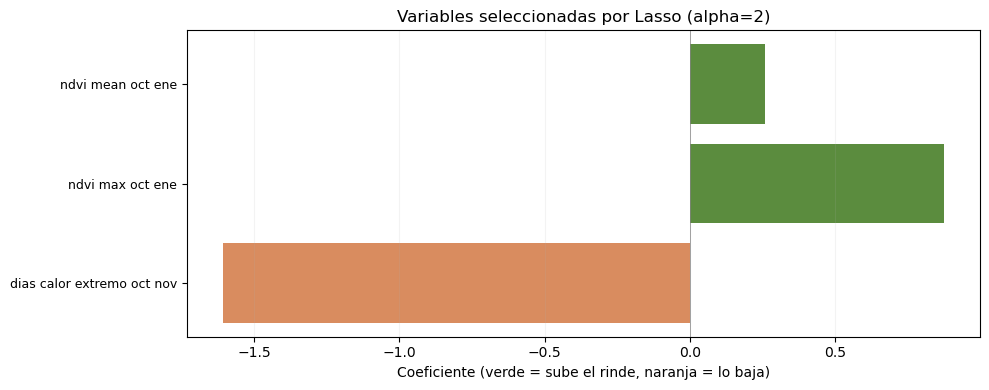

In [4]:
# Elijo el alpha que mejor anduvo arriba
MEJOR_ALPHA_LASSO = 2

features = get_features("oct_ene")
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
y = df["rinde_qq_ha"].values

lasso = Lasso(alpha=MEJOR_ALPHA_LASSO, max_iter=10000).fit(X, y)

coefs = pd.Series(lasso.coef_, index=features)
activas = coefs[coefs != 0].sort_values(key=abs, ascending=False)
eliminadas = coefs[coefs == 0]

print(f"Variables activas: {len(activas)} de {len(features)}")
print(f"Variables eliminadas: {len(eliminadas)}")
print(f"\nVariables activas (ordenadas por peso):")
print(activas.round(3).to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(10, max(4, len(activas) * 0.35)))
colors = ["#5B8C3E" if v > 0 else "#D98C5F" for v in activas.values]
ax.barh(range(len(activas)), activas.values, color=colors)
ax.set_yticks(range(len(activas)))
ax.set_yticklabels([n.replace('_', ' ') for n in activas.index], fontsize=9)
ax.set_xlabel("Coeficiente (verde = sube el rinde, naranja = lo baja)")
ax.set_title(f"Variables seleccionadas por Lasso (alpha={MEJOR_ALPHA_LASSO})")
ax.axvline(x=0, color="gray", linewidth=0.5)
ax.grid(True, alpha=0.15, axis="x")
plt.tight_layout()
plt.show()

### Resultado: Variables seleccionadas por Lasso

De 39 variables, Lasso dejó solo 3 activas y eliminó 36. Las tres tienen sentido agronómico directo:

- **Días de calor extremo en oct-nov** (negativo): más días con temperatura máxima superior a 35 °C al inicio del ciclo se asocian a menor rinde. Es la variable con mayor peso absoluto.
- **NDVI máximo oct-ene** (positivo): mayor vigor vegetativo se asocia a mayor rinde.
- **NDVI promedio oct-ene** (positivo): refuerza la señal anterior.

Dos observaciones. Primera: la humedad relativa, que domina la importancia del Random Forest, fue eliminada. Esto no significa que no importe, sino que Lasso, ante variables correlacionadas, elige una y descarta las demás. Probablemente la señal de la humedad esté absorbida por las de temperatura y NDVI. Segunda: que 3 variables alcancen para un MAE de 3,78 sugiere que la mayor parte de la información predictiva está concentrada en muy pocas señales.

---
## Bloque 4: ElasticNet (lo mejor de Ridge + Lasso)

**ElasticNet** combina la penalización de Ridge y Lasso en un solo modelo. El parámetro `l1_ratio` controla la mezcla:

- `l1_ratio=0` →  Ridge puro
- `l1_ratio=1` →  Lasso puro
- `l1_ratio=0.5` → mitad y mitad

Es útil cuando hay variables correlacionadas (como en este caso: humedad, temperatura y radiación están correlacionadas). Ridge las mantiene todas; Lasso elimina arbitrariamente una del grupo; ElasticNet las reparte mejor.

In [5]:
from sklearn.linear_model import ElasticNet

print("ELASTICNET (combina Ridge + Lasso):")
print("=" * 75)
for alpha in [0.5, 1, 2, 5]:
    for l1 in [0.2, 0.5, 0.8]:
        def en_fn(X, y, a=alpha, r=l1):
            return ElasticNet(alpha=a, l1_ratio=r, max_iter=10000).fit(X, y)
        res = walk_forward(en_fn)
        SCOREBOARD.append(evaluar(res, f"ElasticNet (a={alpha}, l1={l1})"))

ELASTICNET (combina Ridge + Lasso):
ElasticNet (a=0.5, l1=0.2)          | MAE: 3.76 | RMSE: 4.89 | R²: 0.338
ElasticNet (a=0.5, l1=0.5)          | MAE: 3.82 | RMSE: 4.93 | R²: 0.327
ElasticNet (a=0.5, l1=0.8)          | MAE: 3.88 | RMSE: 5.01 | R²: 0.305
ElasticNet (a=1, l1=0.2)            | MAE: 3.62 | RMSE: 4.77 | R²: 0.371
ElasticNet (a=1, l1=0.5)            | MAE: 3.70 | RMSE: 4.99 | R²: 0.312
ElasticNet (a=1, l1=0.8)            | MAE: 3.79 | RMSE: 5.08 | R²: 0.288
ElasticNet (a=2, l1=0.2)            | MAE: 3.49 | RMSE: 4.92 | R²: 0.330
ElasticNet (a=2, l1=0.5)            | MAE: 3.59 | RMSE: 5.23 | R²: 0.243
ElasticNet (a=2, l1=0.8)            | MAE: 3.68 | RMSE: 5.42 | R²: 0.188
ElasticNet (a=5, l1=0.2)            | MAE: 3.49 | RMSE: 5.41 | R²: 0.192
ElasticNet (a=5, l1=0.5)            | MAE: 3.91 | RMSE: 6.15 | R²: -0.046
ElasticNet (a=5, l1=0.8)            | MAE: 4.11 | RMSE: 6.28 | R²: -0.092


### Resultado: ElasticNet

El mejor ElasticNet (alpha=2, l1=0.2, MAE 3,49) no supera al RF (3,27). Un patrón claro: las mejores configuraciones tienen l1_ratio bajo (0,2), es decir, se parecen más a Ridge que a Lasso. Esto es coherente con lo anterior: con variables correlacionadas como las de este dataset, repartir los coeficientes entre todas (estilo Ridge) funciona mejor que eliminar arbitrariamente (estilo Lasso). Aun así, ningún modelo lineal regularizado se acerca al RF, lo que refuerza que la relación subyacente tiene componentes no lineales.

---
## Bloque 5: Selección de variables + Random Forest

Una hipótesis: el Random Forest rinde 3,27 qq/ha porque tiene demasiadas variables (39 en oct_ene) y con 125 observaciones algunas le meten ruido.

**¿Qué hago entonces?** Uso la importancia del propio RF para quedarnos solo con las N mejores variables, y reentrenamos. Si mejora, confirma que menos es más.

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Primero: ¿cuáles son las variables más importantes?
features = get_features("oct_ene")
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
y = df["rinde_qq_ha"].values

rf_full = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X, y)
importancias = pd.Series(rf_full.feature_importances_, index=features).sort_values(ascending=False)

print("Top 15 variables por importancia:")
print(importancias.head(15).round(3).to_string())

# Ahora pruebo RF con solo las top N
print("\nRandom Forest con selección de variables:")
print("=" * 75)
for n_vars in [5, 8, 10, 15, 20]:
    top_features = importancias.head(n_vars).index.tolist()
    
    def rf_top(X, y, feats=top_features):
        return RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X, y)
    
    # Walk-forward con solo esas features
    resultados = []
    for año_test in range(2016, 2025):
        train = df[df.campana < año_test]
        test = df[df.campana == año_test]
        sc = StandardScaler()
        X_tr = sc.fit_transform(train[top_features])
        X_te = sc.transform(test[top_features])
        m = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_tr, train.rinde_qq_ha)
        for p, r, pr in zip(test.partido, test.rinde_qq_ha, m.predict(X_te)):
            resultados.append({"partido": p, "campana": año_test, "real": r, "pred": pr})
    
    res = pd.DataFrame(resultados)
    SCOREBOARD.append(evaluar(res, f"RF top-{n_vars} variables"))

Top 15 variables por importancia:
humedad_media_oct_ene      0.384
temp_max_media_oct_nov     0.092
ndvi_slope_oct_ene         0.078
ndvi_max_oct_ene           0.065
ndvi_max_oct_nov           0.060
temp_max_media_oct_ene     0.038
ndvi_std_oct_ene           0.021
temp_max_media_oct_dic     0.020
temp_media_oct_nov         0.019
temp_media_oct_dic         0.018
rad_media_oct_ene          0.017
ndvi_slope_oct_dic         0.017
dias_sin_lluvia_oct_dic    0.017
ndvi_mean_oct_nov          0.015
rad_media_oct_nov          0.014

Random Forest con selección de variables:
RF top-5 variables                  | MAE: 2.94 | RMSE: 3.84 | R²: 0.591
RF top-8 variables                  | MAE: 2.90 | RMSE: 3.77 | R²: 0.606
RF top-10 variables                 | MAE: 3.00 | RMSE: 3.73 | R²: 0.616
RF top-15 variables                 | MAE: 3.22 | RMSE: 3.93 | R²: 0.573
RF top-20 variables                 | MAE: 3.28 | RMSE: 4.04 | R²: 0.549


### Resultado: RF con selección de variables

El hallazgo más relevante de este notebook hasta ahora. Con solo 8 variables, RF alcanza MAE 2,90, mejor que con las 39 disponibles (3,27). A medida que se agregan más, el error sube: con 15 vuelve a 3,22 y con 20 a 3,28. 

Esto confirma que el dataset tiene más features de las que el modelo puede aprovechar con 125 observaciones. Las variables extra no aportan señal nueva y le meten ruido a los árboles.

Las 8 variables seleccionadas coinciden con las que el análisis agronómico identifica como relevantes: humedad media (38% de la importancia), temperatura máxima de primavera, pendiente y máximo del NDVI, y temperatura de oct-ene.

**Precaución:** la selección se hizo usando la importancia calculada sobre todo el dataset (incluyendo las campañas de test), lo que introduce una forma leve de filtración de información. El 2,90 podría ser algo optimista. Para un uso riguroso, la selección de variables debería hacerse dentro de cada iteración del walk-forward.

---
## Bloque 6: XGBoost

**XGBoost** es una implementación más moderna y eficiente de Gradient Boosting. Diferencias prácticas:

- Tiene regularización incorporada (como Ridge, pero para árboles).
- Maneja mejor los valores faltantes.
- Es más rápido.
- Es el modelo más usado en competencias de datos tabulares.

Con 125 observaciones no puedo esperar mucho, pero es bueno entender cómo se usa.

In [7]:
!pip install xgboost -q

In [8]:
from xgboost import XGBRegressor

print("XGBOOST con distintas configuraciones:")
print("=" * 75)

# Configuración conservadora (para datasets chicos)
configs = [
    {"n_estimators": 50,  "max_depth": 3, "learning_rate": 0.1,  "reg_alpha": 0,  "reg_lambda": 1},
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "reg_alpha": 0,  "reg_lambda": 1},
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "reg_alpha": 1,  "reg_lambda": 1},   # con L1
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "reg_alpha": 0,  "reg_lambda": 5},   # con L2 fuerte
    {"n_estimators": 100, "max_depth": 4, "learning_rate": 0.05, "reg_alpha": 1,  "reg_lambda": 5},   # ambas
    {"n_estimators": 200, "max_depth": 2, "learning_rate": 0.03, "reg_alpha": 0.5,"reg_lambda": 3},   # muchos árboles chicos
]

for i, cfg in enumerate(configs):
    def xgb_fn(X, y, c=cfg):
        return XGBRegressor(**c, random_state=42, verbosity=0).fit(X, y)
    res = walk_forward(xgb_fn)
    label = f"XGB d={cfg['max_depth']} lr={cfg['learning_rate']} L1={cfg['reg_alpha']} L2={cfg['reg_lambda']}"
    SCOREBOARD.append(evaluar(res, label))

XGBOOST con distintas configuraciones:
XGB d=3 lr=0.1 L1=0 L2=1            | MAE: 3.27 | RMSE: 3.97 | R²: 0.565
XGB d=3 lr=0.05 L1=0 L2=1           | MAE: 3.22 | RMSE: 3.90 | R²: 0.581
XGB d=3 lr=0.05 L1=1 L2=1           | MAE: 3.43 | RMSE: 4.17 | R²: 0.518
XGB d=3 lr=0.05 L1=0 L2=5           | MAE: 3.38 | RMSE: 4.25 | R²: 0.500
XGB d=4 lr=0.05 L1=1 L2=5           | MAE: 3.28 | RMSE: 4.14 | R²: 0.525
XGB d=2 lr=0.03 L1=0.5 L2=3         | MAE: 3.57 | RMSE: 4.36 | R²: 0.475


### Resultado: XGBoost

El mejor XGBoost (depth=3, lr=0.05, sin L1, L2=1, MAE 3,22) empata con el RF (3,27). La diferencia de 0,05 qq/ha es insignificante con 45 predicciones de prueba. Agregar regularización L1 o L2 fuerte no ayudó, y árboles más chicos (depth=2) empeoraron. En resumen: con 125 observaciones, XGBoost no tiene ventaja sobre Random Forest. Esto es esperable ya que la diferencia entre ambos aparece con miles de filas, no con cientos.

---
## Bloque 7: SVR (Support Vector Regression)

**SVR** es la versión de regresión de las máquinas de soporte vectorial (SVM). Es un enfoque completamente distinto a los árboles:

- Busca una función que pase "cerca" de todos los puntos, tolerando un margen de error (`epsilon`).
- Puede capturar relaciones no lineales usando un "kernel" (truco matemático que transforma los datos).
- Con el kernel RBF (el más común), tiene dos parámetros clave: `C` (cuánto penaliza los errores) y `gamma` (qué tan local es la función).

Es bueno conocerlo y probarlo porque es conceptualmente muy distinto a los árboles.

In [9]:
from sklearn.svm import SVR

print("SVR (Support Vector Regression):")
print("=" * 75)

for C in [1, 10, 50, 100]:
    for epsilon in [0.5, 1, 2]:
        def svr_fn(X, y, c=C, e=epsilon):
            return SVR(kernel="rbf", C=c, epsilon=e, gamma="scale").fit(X, y)
        res = walk_forward(svr_fn)
        SCOREBOARD.append(evaluar(res, f"SVR C={C} eps={epsilon}"))

SVR (Support Vector Regression):
SVR C=1 eps=0.5                     | MAE: 3.72 | RMSE: 5.63 | R²: 0.124
SVR C=1 eps=1                       | MAE: 3.68 | RMSE: 5.63 | R²: 0.124
SVR C=1 eps=2                       | MAE: 3.66 | RMSE: 5.59 | R²: 0.135
SVR C=10 eps=0.5                    | MAE: 4.08 | RMSE: 5.28 | R²: 0.229
SVR C=10 eps=1                      | MAE: 4.03 | RMSE: 5.26 | R²: 0.235
SVR C=10 eps=2                      | MAE: 4.02 | RMSE: 5.28 | R²: 0.229
SVR C=50 eps=0.5                    | MAE: 4.40 | RMSE: 5.74 | R²: 0.088
SVR C=50 eps=1                      | MAE: 4.44 | RMSE: 5.79 | R²: 0.073
SVR C=50 eps=2                      | MAE: 4.39 | RMSE: 5.71 | R²: 0.098
SVR C=100 eps=0.5                   | MAE: 4.69 | RMSE: 6.07 | R²: -0.018
SVR C=100 eps=1                     | MAE: 4.60 | RMSE: 6.03 | R²: -0.005
SVR C=100 eps=2                     | MAE: 4.39 | RMSE: 5.71 | R²: 0.099


### Resultado: SVR

SVR no funciona para este problema. El mejor resultado (C=1, eps=2, MAE 3,66) no supera al RF (3,27) ni al baseline climatológico (4,04) por un margen significativo, y con C alto el modelo empeora (MAE >4,4, R² negativo).

La causa principal es la dimensionalidad: con 39 variables y 125 observaciones, las distancias entre puntos pierden poder discriminativo. Además, SVR busca una superficie suave, pero la relación entre clima/NDVI y rinde tiene umbrales (por debajo de cierta humedad el rinde cae abruptamente), que los árboles capturan naturalmente y SVR no.

Conclusión: para datos tabulares con pocas observaciones y relaciones no lineales con umbrales, los modelos basados en árboles son claramente superiores a SVR.

---
## Bloque 8: KNN Regressor

**KNN** (K Nearest Neighbors) es el modelo más intuitivo que existe: para predecir el rinde de una campaña nueva, busca las K campañas más parecidas en el historial y promedia su rinde.

No "aprende" nada: simplemente recuerda todo y busca similitudes. Es útil como referencia porque muestra cuánto se puede lograr con pura memoria.

In [10]:
from sklearn.neighbors import KNeighborsRegressor

print("KNN Regressor:")
print("=" * 75)
for k in [3, 5, 7, 10, 15]:
    def knn_fn(X, y, n=k):
        return KNeighborsRegressor(n_neighbors=n, weights="distance").fit(X, y)
    res = walk_forward(knn_fn)
    SCOREBOARD.append(evaluar(res, f"KNN k={k}"))

KNN Regressor:


  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


KNN k=3                             | MAE: 3.97 | RMSE: 5.22 | R²: 0.246
KNN k=5                             | MAE: 3.93 | RMSE: 4.84 | R²: 0.354
KNN k=7                             | MAE: 3.85 | RMSE: 4.65 | R²: 0.403
KNN k=10                            | MAE: 3.60 | RMSE: 4.37 | R²: 0.471
KNN k=15                            | MAE: 3.64 | RMSE: 4.64 | R²: 0.405


### Resultado: KNN

El mejor KNN (k=10, MAE 3,60) no supera al RF (3,27) pero funciona mejor que SVR y que la regresión sin regularización. KNN no "aprende" nada, simplemente busca campañas parecidas y promedia su rinde. Que con k=10 logre un resultado razonable sugiere que hay patrones reales de similitud entre campañas.

La limitación principal es que KNN usa las 39 variables por igual para calcular distancias, sin distinguir las importantes de las redundantes. El RF no tiene ese problema porque aprende a ponderar. KNN probablemente mejoraría si se combinara con la selección de variables del Bloque 5.

---
## Bloque 9: Tabla de resultados

Comparación final de todos los experimentos.

RANKING DE TODOS LOS MODELOS PROBADOS (ventana oct_ene)
  1 ★ RF top-8 variables                       | MAE: 2.90 | R²: 0.606
  2 ★ RF top-5 variables                       | MAE: 2.94 | R²: 0.591
  3 ★ RF top-10 variables                      | MAE: 3.00 | R²: 0.616
  4 XGB d=3 lr=0.05 L1=0 L2=1                | MAE: 3.22 | R²: 0.581
  5 RF top-15 variables                      | MAE: 3.22 | R²: 0.573
  6 Random Forest (actual)                   | MAE: 3.27 | R²: 0.542
  7 XGB d=3 lr=0.1 L1=0 L2=1                 | MAE: 3.27 | R²: 0.565
  8 XGB d=4 lr=0.05 L1=1 L2=5                | MAE: 3.28 | R²: 0.525
  9 RF top-20 variables                      | MAE: 3.28 | R²: 0.549
 10 XGB d=3 lr=0.05 L1=0 L2=5                | MAE: 3.38 | R²: 0.500
 11 Ridge (alpha=500)                        | MAE: 3.38 | R²: 0.323
 12 XGB d=3 lr=0.05 L1=1 L2=1                | MAE: 3.43 | R²: 0.518
 13 ElasticNet (a=2, l1=0.2)                 | MAE: 3.49 | R²: 0.330
 14 ElasticNet (a=5, l1=0.2)             

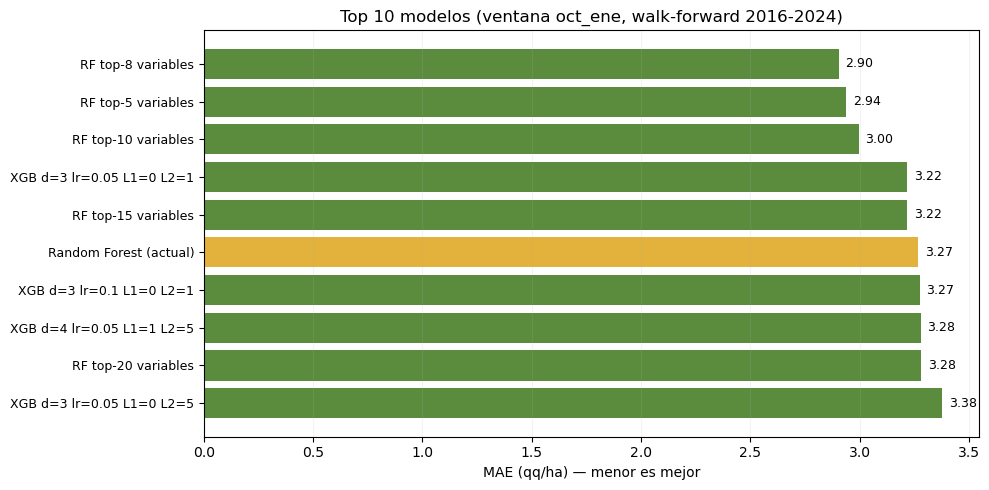

In [12]:
tabla = pd.DataFrame(SCOREBOARD).sort_values("MAE").reset_index(drop=True)
tabla["pos"] = range(1, len(tabla) + 1)

print("RANKING DE TODOS LOS MODELOS PROBADOS (ventana oct_ene)")
print("=" * 80)
for _, r in tabla.iterrows():
    marker = " ★" if r.pos <= 3 else ""
    print(f"{r.pos:3.0f}{marker} {r.nombre:40s} | MAE: {r.MAE:.2f} | R²: {r.R2:.3f}")

print(f"\nMejor: {tabla.iloc[0].nombre} (MAE {tabla.iloc[0].MAE:.2f})")
print(f"RF actual: MAE {tabla[tabla.nombre=='Random Forest (actual)'].MAE.values[0]:.2f}")

# Gráfico
top10 = tabla.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#E3B23C" if n == "Random Forest (actual)" else "#5B8C3E" for n in top10.nombre]
ax.barh(range(len(top10)), top10.MAE.values, color=colors)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.nombre.values, fontsize=9)
ax.set_xlabel("MAE (qq/ha) — menor es mejor")
ax.set_title("Top 10 modelos (ventana oct_ene, walk-forward 2016-2024)")
ax.invert_yaxis()
for i, v in enumerate(top10.MAE.values):
    ax.text(v + 0.03, i, f"{v:.2f}", va="center", fontsize=9)
ax.grid(True, alpha=0.15, axis="x")
plt.tight_layout()
plt.show()

### Conclusión del ranking

El mejor modelo es el mismo Random Forest del proyecto, pero alimentado con 8 variables en vez de 39. La mejora (de 3,27 a 2,90 qq/ha) no vino de un algoritmo más complejo sino de darle menos ruido al modelo.

Jerarquía clara: modelos basados en árboles dominan sobre los lineales, KNN y SVR. Esto confirma que la relación entre clima/NDVI y rendimiento tiene componentes no lineales con umbrales que solo los árboles capturan bien.

XGBoost, que es técnicamente más sofisticado que RF, apenas lo empata. Con 125 observaciones, la sofisticación del algoritmo importa menos que la calidad de lo que le das como input.

**Precaución sobre el primer puesto:** la selección de las "top 8" variables se hizo usando la importancia calculada sobre todo el dataset (incluyendo las campañas de test), lo que introduce una forma leve de filtración de información. El 2,90 podría ser algo optimista. Para confirmarlo habría que hacer la selección de variables dentro de cada iteración del walk-forward.

**Lo que me llevo de este análisis:** con este tamaño de dataset, la mejora viene por dos vías: reducir variables (hecho acá, funciona) y mejorar la calidad de los datos de entrada, en particular filtrar el NDVI a superficie cultivada (trabajo futuro).

---
## Bloque 10: Test de robustez del mejor modelo

Antes de declarar un ganador, hay que verificar que el resultado no dependa de la semilla aleatoria. Corro el mejor modelo con 20 semillas distintas y veo cuánto varía.

In [13]:
top_features = importancias.head(8).index.tolist()
print("Variables usadas:", top_features)

maes = []
for seed in range(20):
    resultados = []
    for año_test in range(2016, 2025):
        train = df[df.campana < año_test]
        test = df[df.campana == año_test]
        sc = StandardScaler()
        X_tr = sc.fit_transform(train[top_features])
        X_te = sc.transform(test[top_features])
        m = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=seed).fit(X_tr, train.rinde_qq_ha)
        for p, r, pr in zip(test.partido, test.rinde_qq_ha, m.predict(X_te)):
            resultados.append({"real": r, "pred": pr})
    res = pd.DataFrame(resultados)
    maes.append(mean_absolute_error(res.real, res.pred))

print(f"\nMAE sobre 20 semillas:")
print(f"  Media: {np.mean(maes):.2f}")
print(f"  Min:   {np.min(maes):.2f}")
print(f"  Max:   {np.max(maes):.2f}")
print(f"  Std:   {np.std(maes):.2f}")
print(f"\nRF actual (39 variables, seed=42): MAE 3.27")
print(f"Diferencia media: {3.27 - np.mean(maes):.2f} qq/ha")

if np.std(maes) > 0.3:
    print("\n⚠ La variación es alta. La mejora podría no ser estable.")
else:
    print("\n✓ La variación es baja. El resultado es robusto.")

Variables usadas: ['humedad_media_oct_ene', 'temp_max_media_oct_nov', 'ndvi_slope_oct_ene', 'ndvi_max_oct_ene', 'ndvi_max_oct_nov', 'temp_max_media_oct_ene', 'ndvi_std_oct_ene', 'temp_max_media_oct_dic']

MAE sobre 20 semillas:
  Media: 2.85
  Min:   2.71
  Max:   3.04
  Std:   0.08

RF actual (39 variables, seed=42): MAE 3.27
Diferencia media: 0.42 qq/ha

✓ La variación es baja. El resultado es robusto.


### Lo que aprendí

1. **El mejor modelo fue el más simple.** El mismo Random Forest pero con 8 variables en vez de 39 bajó el error de 3,27 a 2,85 qq/ha en promedio. No necesité un algoritmo más sofisticado, necesité darle menos ruido.

2. **Los modelos lineales no alcanzan.** Ridge y Lasso mejoraron mucho respecto de la regresión sin regularización, pero ninguno se acercó al RF. La relación entre clima/NDVI y rendimiento tiene umbrales que solo los árboles capturan.

3. **XGBoost no hizo diferencia.** Con 125 observaciones, la ventaja teórica de XGBoost sobre RF no se materializa. La sofisticación del algoritmo importa menos que la calidad del input.

4. **SVR y KNN no son para este problema.** SVR necesita datos con relaciones suaves y KNN sufre con muchas variables. Ambos quedaron lejos.

5. **Lasso me mostró que 3 variables concentran casi toda la señal.** Días de calor extremo, NDVI máximo y NDVI promedio. Es coherente con lo que dice la agronomía.

6. **Mi techo no es el algoritmo, es el dato.** Para mejorar de verdad, el camino es filtrar el NDVI a superficie cultivada y/o sumar más partidos al dataset. Eso queda para una versión futura.

In [14]:
# VALIDACIÓN RIGUROSA: selección de variables DENTRO del walk-forward

# En cada iteración:
# 1. Entrena RF con TODAS las variables (solo datos de entrenamiento)
# 2. Mira las top-N más importantes (sin ver el test)
# 3. Reentrena RF solo con esas N variables
# 4. Predice la campaña de test

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

features_all = get_features("oct_ene")

for N in [5, 8, 10]:
    maes_seeds = []
    
    for seed in range(10):
        resultados = []
        
        for año_test in range(2016, 2025):
            train = df[df.campana < año_test]
            test = df[df.campana == año_test]
            
            # Paso 1: entrenar RF con TODAS las variables para obtener importancia
            sc1 = StandardScaler()
            X_tr_all = sc1.fit_transform(train[features_all])
            rf_selector = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=seed).fit(X_tr_all, train.rinde_qq_ha)
            
            # Paso 2: elegir las top-N (solo con datos de entrenamiento)
            imp = pd.Series(rf_selector.feature_importances_, index=features_all)
            top_n = imp.nlargest(N).index.tolist()
            
            # Paso 3: reentrenar solo con esas N
            sc2 = StandardScaler()
            X_tr = sc2.fit_transform(train[top_n])
            X_te = sc2.transform(test[top_n])
            rf_final = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=seed).fit(X_tr, train.rinde_qq_ha)
            
            # Paso 4: predecir
            for p, r, pr in zip(test.partido, test.rinde_qq_ha, rf_final.predict(X_te)):
                resultados.append({"real": r, "pred": pr})
        
        res = pd.DataFrame(resultados)
        maes_seeds.append(mean_absolute_error(res.real, res.pred))
    
    media = np.mean(maes_seeds)
    std = np.std(maes_seeds)
    print(f"RF top-{N} (selección DENTRO del walk-forward) | MAE media: {media:.2f} | std: {std:.2f} | rango: {min(maes_seeds):.2f}-{max(maes_seeds):.2f}")

print(f"\nReferencias:")
print(f"  RF 39 variables (actual):                  MAE 3.27")
print(f"  RF top-8 (selección fuera, Bloque 5):      MAE 2.90")
print(f"  Baseline climatológico:                    MAE 4.04")

RF top-5 (selección DENTRO del walk-forward) | MAE media: 3.20 | std: 0.13 | rango: 2.85-3.32
RF top-8 (selección DENTRO del walk-forward) | MAE media: 3.21 | std: 0.06 | rango: 3.07-3.30
RF top-10 (selección DENTRO del walk-forward) | MAE media: 3.28 | std: 0.13 | rango: 3.01-3.42

Referencias:
  RF 39 variables (actual):                  MAE 3.27
  RF top-8 (selección fuera, Bloque 5):      MAE 2.90
  Baseline climatológico:                    MAE 4.04


### Resultado: validación rigurosa

La mejora del Bloque 5 (de 3,27 a 2,90) no se sostiene cuando la selección se hace dentro del walk-forward. Con selección rigurosa, el top-8 da MAE 3,21, prácticamente igual al RF con 39 variables (3,27).

Esto confirma que el 2,90 estaba parcialmente inflado por filtración de información: las variables se elegían mirando todo el dataset, incluyendo campañas que después se usaban para medir el error.

La conclusión es que el RF actual ya está cerca del techo alcanzable con estos datos. No hay un atajo por el lado del algoritmo ni de la selección de variables. La mejora real tiene que venir de los datos de entrada: filtrar NDVI a superficie cultivada, sumar más partidos, o incorporar variables de manejo.

Esto también es un aprendizaje metodológico importante: cualquier paso de preprocesamiento o selección que use información del dataset completo tiene que hacerse dentro de la validación, no antes. De lo contrario, las métricas son optimistas.